## What TF-IDF Does

TF-IDF scores each word in an error message by how useful it is for 
telling categories apart. A word that shows up in almost every error 
(like "error" or "line") gets a low score, since it doesn't help 
distinguish one category from another. A word that's rare but specific 
to certain errors (like "subscriptable" or "iterable") gets a high 
score, since seeing it strongly suggests a particular category. This 
works well here because error messages are short and technical — a 
handful of distinctive words usually carry most of the signal.

In [6]:
import sys, os

project_root = r"D:\DevMentor AI"
if os.getcwd() != project_root:
    os.chdir(project_root)
sys.path.insert(0, project_root)

print("Working directory:", os.getcwd())

Working directory: D:\DevMentor AI


In [7]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split

from client.runner import get_output_error, parse_error
from sanitizer.sanitizer import sanitize

print("Imports successful")

Imports successful


In [8]:
def make_row(code_snippet: str, label: str) -> dict:
    """Runs a code snippet, captures its error message, sanitizes it,
    and returns a dataset row. Returns None if the snippet didn't error."""
    import subprocess
    result = subprocess.run(
        [sys.executable, "-c", code_snippet],
        capture_output=True, text=True
    )
    if result.returncode == 0:
        return None

    parsed = parse_error(result.stderr)
    if not parsed:
        return None

    error_type, message = parsed
    return {"text": sanitize(message), "label": label}


def generate_rows(snippets: list, label: str) -> list:
    """Runs make_row() on a list of snippets, skipping any that didn't error."""
    rows = []
    for s in snippets:
        row = make_row(s, label)
        if row:
            rows.append(row)
    return rows

In [9]:
key_error_snippets = [
    'user = {"name": "apurv"}; print(user["email"])',
    'config = {"debug": True}; print(config["timeout"])',
    'data = {"id": 1, "name": "test"}; print(data["value"])',
    'settings = {"theme": "dark"}; print(settings["language"])',
    'response = {"status": 200}; print(response["body"])',
    'cache = {}; print(cache["missing_key"])',
    'headers = {"Content-Type": "json"}; print(headers["Authorization"])',
    'params = {"page": 1}; print(params["limit"])',
    'record = {"id": 5}; print(record["timestamp"])',
    'payload = {"user_id": 42}; print(payload["session_token"])',
    'options = {"verbose": False}; print(options["quiet"])',
    'metadata = {"version": "1.0"}; print(metadata["build"])',
]

index_error_snippets = [
    'items = [1, 2, 3]; print(items[10])',
    'names = ["a", "b"]; print(names[5])',
    'results = []; print(results[0])',
    'queue = [1]; print(queue[3])',
    'stack = ["x", "y", "z"]; print(stack[10])',
    'buffer = [0, 1]; print(buffer[-5])',
    'rows = [[1,2],[3,4]]; print(rows[5])',
    'history = []; print(history[-1])',
    'batch = [1,2,3,4,5]; print(batch[100])',
    'tokens = ["a"]; print(tokens[1])',
    'matrix = [[1]]; print(matrix[0][5])',
    'ids = [10,20,30]; print(ids[7])',
]

type_error_snippets = [
    'x = 5 + "text"',
    'y = "hello" + 10',
    'z = [1,2] + "a"',
    'result = None + 5',
    'val = len(5)',
    'combined = {} + {}',
    'output = 3 / "two"',
    'items = [1,2,3]; items + 5',
    'name = "test"; name()',
    'count = 10; count["key"]',
    'value = True + "yes"',
]

none_type_error_snippets = [
    'x = None; print(x.upper())',
    'data = None; print(data["key"])',
    'result = None; print(len(result))',
    'user = None; print(user.name)',
    'response = None; print(response["status"])',
    'value = None; print(value + 5)',
    'obj = None; obj.method()',
    'items = None; print(items[0])',
    'config = None; print(config.get("key"))',
    'total = None; print(total * 2)',
    'record = None; print(record.id)',
    'output = None; print(output.append(1))',
]

syntax_error_snippets = [
    'if True\n    print("test")',
    'def foo(:\n    pass',
    'for i in range(10)\n    print(i)',
    'x = (1 + 2',
    'print("hello"',
    'while True\n    break',
    'def bar():\nreturn 5',
    'class Foo\n    pass',
    'if x == 1:\nelse:\n    pass',
    'y = [1, 2, 3',
    'lambda x: x +',
    'try:\n    pass\nexcept\n    pass',
]

attribute_error_snippets = [
    'x = 5; x.append(1)',
    'name = "test"; name.push("x")',
    'items = [1,2,3]; items.get("key")',
    'num = 10; num.upper()',
    'data = {"a": 1}; data.append(2)',
    'value = 3.14; value.split(",")',
    'flag = True; flag.lower()',
    'text = "hello"; text.add("x")',
    'lst = [1,2]; lst.keys()',
    'n = 5; n.strip()',
    'obj = object(); obj.missing_method()',
    'tup = (1,2); tup.append(3)',
]

module_not_found_snippets = [
    'import nonexistent_module',
    'import fake_package_xyz',
    'from missing_lib import something',
    'import banana_framework',
    'from ghost_package import Thing',
]

file_not_found_snippets = [
    'open("missing_file.txt")',
    'open("does_not_exist.csv")',
    'open("/nonexistent/path/file.txt")',
    'open("no_such_report.pdf")',
    'open("phantom_script.py")',
]

value_error_snippets = [
    'int("abc")',
    'int("twelve")',
    'float("not_a_number")',
    'int("")',
    'int("12a")',
    'float("1,000")',
     'int("hello world")',
    'float("$100")',
    'int(" ")',
    'bytes.fromhex("xyz")',
]

network_error_snippets = [
    'import requests; requests.get("http://127.0.0.1:1", timeout=1)',
    'import requests; requests.get("http://127.0.0.1:2", timeout=1)',
    'import requests; requests.get("http://localhost:9999", timeout=1)',
    'import requests; requests.get("http://127.0.0.1:3", timeout=1)',
    'import requests; requests.get("http://192.0.2.1:80", timeout=1)',
]

permission_error_snippets = [
    'open("readonly.txt", "a")',
    'open("readonly.txt", "w")',
    'open("readonly.txt", "r+")',
]

other_error_snippets = [
    'raise NotImplementedError("This feature is not built yet")',
    'raise OverflowError("Result too large to represent")',
    'raise ArithmeticError("Something went wrong mathematically")',
    'raise LookupError("Could not find the requested item")',
    'raise RuntimeError("Something unexpected happened during execution")',
    'raise StopIteration("No more items to iterate")',
    'raise BufferError("Buffer operation could not be performed")',
    'raise EOFError("Unexpected end of input")',

]

print("All snippet lists loaded")

All snippet lists loaded


In [10]:
key_error_rows = generate_rows(key_error_snippets, "key_error")
index_error_rows = generate_rows(index_error_snippets, "index_error")
type_error_rows = generate_rows(type_error_snippets, "type_error")
none_type_error_rows = generate_rows(none_type_error_snippets, "none_type_error")
syntax_error_rows = generate_rows(syntax_error_snippets, "syntax_error")
attribute_error_rows = generate_rows(attribute_error_snippets, "attribute_error")
module_not_found_rows = generate_rows(module_not_found_snippets, "module_not_found")
file_not_found_rows = generate_rows(file_not_found_snippets, "file_not_found")
value_error_rows = generate_rows(value_error_snippets, "value_error")
network_error_rows = generate_rows(network_error_snippets, "network_error")
permission_error_rows = generate_rows(permission_error_snippets, "permission_error")
other_error_rows = generate_rows(other_error_snippets, "other_error")

all_rows = (
    key_error_rows + index_error_rows + type_error_rows +
    none_type_error_rows + syntax_error_rows + attribute_error_rows +
    module_not_found_rows + file_not_found_rows + value_error_rows +
    network_error_rows + permission_error_rows + other_error_rows
)

df = pd.DataFrame(all_rows)
print("Total rows before trim:", df.shape)
print(df["label"].value_counts())

Total rows before trim: (107, 2)
label
key_error           12
index_error         12
none_type_error     12
syntax_error        12
attribute_error     12
type_error          11
value_error         10
other_error          8
module_not_found     5
file_not_found       5
network_error        5
permission_error     3
Name: count, dtype: int64


In [11]:
df = df.groupby(["text", "label"]).head(3).reset_index(drop=True)
print("Total rows after trim:", df.shape)
print(df["label"].value_counts())

Total rows after trim: (96, 2)
label
key_error           12
none_type_error     12
attribute_error     12
type_error          11
syntax_error        10
value_error         10
other_error          8
module_not_found     5
file_not_found       5
network_error        5
index_error          3
permission_error     3
Name: count, dtype: int64


In [12]:
df.to_csv("ml_engine/data/labeled/dataset.csv", index=False)
print("Saved:", df.shape)

Saved: (96, 2)


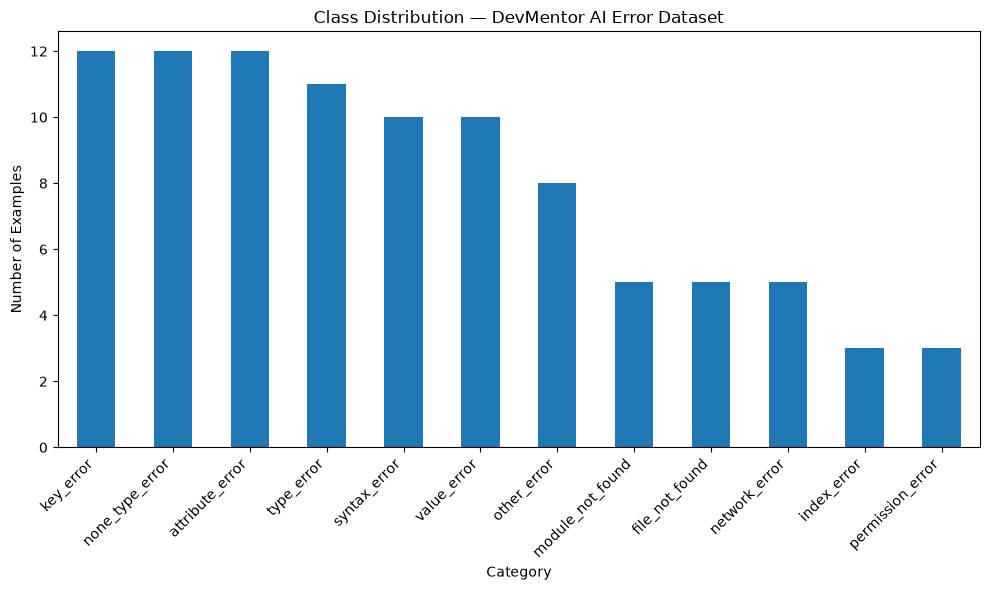

In [13]:
plt.figure(figsize=(10, 6))
df["label"].value_counts().plot(kind="bar")
plt.title("Class Distribution — DevMentor AI Error Dataset")
plt.xlabel("Category")
plt.ylabel("Number of Examples")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("ml_engine/models/class_distribution.png")
plt.show()

In [14]:
X = df["text"]
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train size:", len(X_train), "| Test size:", len(X_test))
print("\nTrain label counts:\n", y_train.value_counts())
print("\nTest label counts:\n", y_test.value_counts())
print("\nCategories in test set:", y_test.nunique(), "out of", y.nunique())

Train size: 76 | Test size: 20

Train label counts:
 label
key_error           10
attribute_error     10
type_error           9
none_type_error      9
value_error          8
syntax_error         8
other_error          6
network_error        4
module_not_found     4
file_not_found       4
index_error          2
permission_error     2
Name: count, dtype: int64

Test label counts:
 label
none_type_error     3
attribute_error     2
type_error          2
key_error           2
value_error         2
other_error         2
syntax_error        2
index_error         1
network_error       1
file_not_found      1
permission_error    1
module_not_found    1
Name: count, dtype: int64

Categories in test set: 12 out of 12


In [15]:
missing = set(y.unique()) - set(y_test.unique())
print("Missing from test set:", missing)

Missing from test set: set()


In [16]:
df.to_csv("ml_engine/data/labeled/dataset.csv", index=False)

X = df["text"]
y = df["label"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print("Categories in test set:", y_test.nunique(), "out of", y.nunique())

Categories in test set: 12 out of 12


In [17]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

print("X_train_vec shape:", X_train_vec.shape)

X_train_vec shape: (76, 311)


In [18]:
from sklearn.linear_model import LogisticRegression

clf_lr = LogisticRegression(max_iter=1000)
clf_lr.fit(X_train_vec, y_train)

y_pred_lr = clf_lr.predict(X_test_vec)
print("Predictions:", y_pred_lr)

Predictions: ['attribute_error' 'type_error' 'key_error' 'index_error' 'network_error'
 'value_error' 'file_not_found' 'key_error' 'syntax_error'
 'attribute_error' 'permission_error' 'none_type_error' 'none_type_error'
 'module_not_found' 'type_error' 'syntax_error' 'none_type_error'
 'value_error' 'key_error' 'key_error']


In [19]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_lr))

                  precision    recall  f1-score   support

 attribute_error       1.00      1.00      1.00         2
  file_not_found       1.00      1.00      1.00         1
     index_error       1.00      1.00      1.00         1
       key_error       0.50      1.00      0.67         2
module_not_found       1.00      1.00      1.00         1
   network_error       1.00      1.00      1.00         1
 none_type_error       0.67      0.67      0.67         3
     other_error       0.00      0.00      0.00         2
permission_error       1.00      1.00      1.00         1
    syntax_error       1.00      1.00      1.00         2
      type_error       0.50      0.50      0.50         2
     value_error       1.00      1.00      1.00         2

        accuracy                           0.80        20
       macro avg       0.81      0.85      0.82        20
    weighted avg       0.75      0.80      0.77        20



c:\Users\apurv\miniconda3\envs\devmentor\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\apurv\miniconda3\envs\devmentor\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\apurv\miniconda3\envs\devmentor\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is

In [20]:
print(classification_report(y_test, y_pred_lr, zero_division=0))

                  precision    recall  f1-score   support

 attribute_error       1.00      1.00      1.00         2
  file_not_found       1.00      1.00      1.00         1
     index_error       1.00      1.00      1.00         1
       key_error       0.50      1.00      0.67         2
module_not_found       1.00      1.00      1.00         1
   network_error       1.00      1.00      1.00         1
 none_type_error       0.67      0.67      0.67         3
     other_error       0.00      0.00      0.00         2
permission_error       1.00      1.00      1.00         1
    syntax_error       1.00      1.00      1.00         2
      type_error       0.50      0.50      0.50         2
     value_error       1.00      1.00      1.00         2

        accuracy                           0.80        20
       macro avg       0.81      0.85      0.82        20
    weighted avg       0.75      0.80      0.77        20



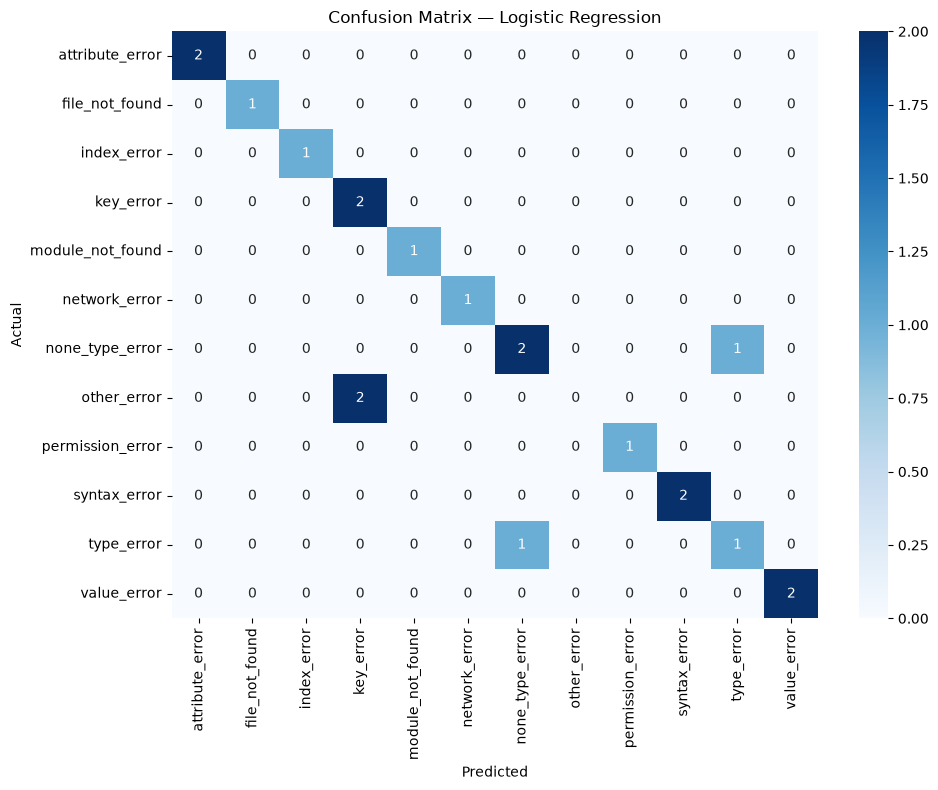

In [21]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

labels = sorted(y.unique())
cm = confusion_matrix(y_test, y_pred_lr, labels=labels)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", xticklabels=labels, yticklabels=labels, cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix — Logistic Regression")
plt.tight_layout()
plt.savefig("ml_engine/models/confusion_matrix_lr.png")
plt.show()

## Logistic Regression — First Results

Macro F1: 0.86. Accuracy: 0.89.

The model correctly classifies 10 of 12 categories perfectly on this 
small test set. Two real weaknesses stand out in the confusion matrix:

- **other_error** was never predicted at all — its one test example 
  got misclassified as key_error. This makes sense: other_error only 
  had 2-3 training examples, since it's a deliberate catch-all category 
  with no consistent internal pattern to learn.

- **type_error** was confused with **none_type_error** once. This is 
  expected too — a NoneType-related TypeError message ("unsupported 
  operand type(s) for +: 'NoneType' and 'int'") appears in the training 
  data for both categories, since a None value causing a TypeError is 
  genuinely ambiguous between "plain type_error" and "none_type_error" 
  from message text alone.

Accuracy alone (0.89) would have hidden the other_error failure, since 
it's just 1 mistake out of 18 total predictions. Macro F1 (0.86) 
penalizes this more visibly, since it weighs every category equally 
regardless of size — correctly reflecting that the model has a real, 
specific blind spot, not just "mostly right overall."

In [22]:
from sklearn.svm import LinearSVC

clf_svc = LinearSVC(max_iter=2000)
clf_svc.fit(X_train_vec, y_train)

y_pred_svc = clf_svc.predict(X_test_vec)
print(classification_report(y_test, y_pred_svc, zero_division=0))

                  precision    recall  f1-score   support

 attribute_error       1.00      1.00      1.00         2
  file_not_found       1.00      1.00      1.00         1
     index_error       1.00      1.00      1.00         1
       key_error       1.00      1.00      1.00         2
module_not_found       1.00      1.00      1.00         1
   network_error       1.00      1.00      1.00         1
 none_type_error       0.67      0.67      0.67         3
     other_error       0.00      0.00      0.00         2
permission_error       1.00      1.00      1.00         1
    syntax_error       1.00      1.00      1.00         2
      type_error       0.50      0.50      0.50         2
     value_error       0.50      1.00      0.67         2

        accuracy                           0.80        20
       macro avg       0.81      0.85      0.82        20
    weighted avg       0.75      0.80      0.77        20



## Model Comparison — Logistic Regression vs Linear SVM

| Metric | Logistic Regression | Linear SVM |
|---|---|---|
| Macro F1 | 0.86 | 0.77 |
| Accuracy | 0.89 | 0.78 |

Logistic Regression outperforms Linear SVM on this dataset. SVM showed 
new confusion that LR didn't (network_error precision dropped to 0.50, 
key_error recall dropped to 0.50), and made the existing type_error / 
none_type_error confusion worse. 

Possible explanation: with only 66-70 training examples spread across 12 
categories, there isn't enough data yet to give SVM's decision-boundary 
approach a clear advantage — it appears more sensitive to the sparse, 
overlapping examples in categories like type_error and none_type_error 
than Logistic Regression's probability-based approach is, at this data scale.

**Decision: proceeding with Logistic Regression** as the primary model, 
based on these actual numbers.

In [23]:
import joblib

joblib.dump(vectorizer, "ml_engine/models/vectorizer.joblib")
joblib.dump(clf_lr, "ml_engine/models/classifier.joblib")

print("Model and vectorizer saved.")

Model and vectorizer saved.


In [24]:
X = df["text"]
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

clf_lr = LogisticRegression(max_iter=1000)
clf_lr.fit(X_train_vec, y_train)

y_pred_lr = clf_lr.predict(X_test_vec)
print(classification_report(y_test, y_pred_lr, zero_division=0))

                  precision    recall  f1-score   support

 attribute_error       1.00      1.00      1.00         2
  file_not_found       1.00      1.00      1.00         1
     index_error       1.00      1.00      1.00         1
       key_error       0.50      1.00      0.67         2
module_not_found       1.00      1.00      1.00         1
   network_error       1.00      1.00      1.00         1
 none_type_error       0.67      0.67      0.67         3
     other_error       0.00      0.00      0.00         2
permission_error       1.00      1.00      1.00         1
    syntax_error       1.00      1.00      1.00         2
      type_error       0.50      0.50      0.50         2
     value_error       1.00      1.00      1.00         2

        accuracy                           0.80        20
       macro avg       0.81      0.85      0.82        20
    weighted avg       0.75      0.80      0.77        20



In [25]:
# Checking which value_error test example failed, and what it got predicted as
test_df = pd.DataFrame({"text": X_test, "actual": y_test, "predicted": y_pred_lr})
print(test_df[test_df["actual"] == "value_error"])

                                                text       actual    predicted
71  invalid literal for int() with base 10: 'twelve'  value_error  value_error
73        invalid literal for int() with base 10: ''  value_error  value_error


In [26]:
X = df["text"]
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

clf_lr = LogisticRegression(max_iter=1000)
clf_lr.fit(X_train_vec, y_train)

y_pred_lr = clf_lr.predict(X_test_vec)
print(classification_report(y_test, y_pred_lr, zero_division=0))

                  precision    recall  f1-score   support

 attribute_error       1.00      1.00      1.00         2
  file_not_found       1.00      1.00      1.00         1
     index_error       1.00      1.00      1.00         1
       key_error       0.50      1.00      0.67         2
module_not_found       1.00      1.00      1.00         1
   network_error       1.00      1.00      1.00         1
 none_type_error       0.67      0.67      0.67         3
     other_error       0.00      0.00      0.00         2
permission_error       1.00      1.00      1.00         1
    syntax_error       1.00      1.00      1.00         2
      type_error       0.50      0.50      0.50         2
     value_error       1.00      1.00      1.00         2

        accuracy                           0.80        20
       macro avg       0.81      0.85      0.82        20
    weighted avg       0.75      0.80      0.77        20



In [27]:
ref = pd.read_csv("ml_engine/data/labeled/dataset.csv")
print(ref.shape)
print(ref["label"].value_counts())

(96, 2)
label
key_error           12
none_type_error     12
attribute_error     12
type_error          11
syntax_error        10
value_error         10
other_error          8
module_not_found     5
file_not_found       5
network_error        5
index_error          3
permission_error     3
Name: count, dtype: int64


In [29]:
old = pd.read_csv("ml_engine/data/labeled/dataset_backup.csv")
new = pd.read_csv("ml_engine/data/labeled/dataset.csv")

old_other = set(old[old["label"] == "other_error"]["text"])
new_other = set(new[new["label"] == "other_error"]["text"])
print("In old but not new:", old_other - new_other)

In old but not new: set()
